# Day 50 — Least Squares SVM sur le Dataset Ionosphère

**Algorithme :** Least Squares Support Vector Machine (LS-SVM) — implémentation from scratch  
**Dataset :** Ionosphere (UCI) — classification de signaux radar  
**Split :** 70 % train / 15 % validation / 15 % test  
**Objectif :** Classer les retours radar en *good* (signal structuré) vs *bad* (bruit)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from scipy.linalg import solve

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

  IONOSPHERE — APERÇU GÉNÉRAL
  Samples      : 351
  Features     : 34
  Classes      : {'g': np.int64(225), 'b': np.int64(126)}
  Valeurs NaN  : 0

  Features constantes : ['a02']  → supprimées

  STATISTIQUES DESCRIPTIVES (premières features)
           a01      a03      a04      a05      a06      a07      a08      a09
count  351.000  351.000  351.000  351.000  351.000  351.000  351.000  351.000
mean     0.892    0.641    0.044    0.601    0.116    0.550    0.119    0.512
std      0.311    0.498    0.441    0.520    0.461    0.493    0.521    0.507
min      0.000   -1.000   -1.000   -1.000   -1.000   -1.000   -1.000   -1.000
25%      1.000    0.472   -0.065    0.413   -0.025    0.211   -0.055    0.087
50%      1.000    0.871    0.016    0.809    0.023    0.729    0.015    0.684
75%      1.000    1.000    0.194    1.000    0.335    0.969    0.446    0.953
max      1.000    1.000    1.000    1.000    1.000    1.000    1.000    1.000
  FEATURES À FAIBLE VARIANCE (std < 0.1)
  Aucune (ho

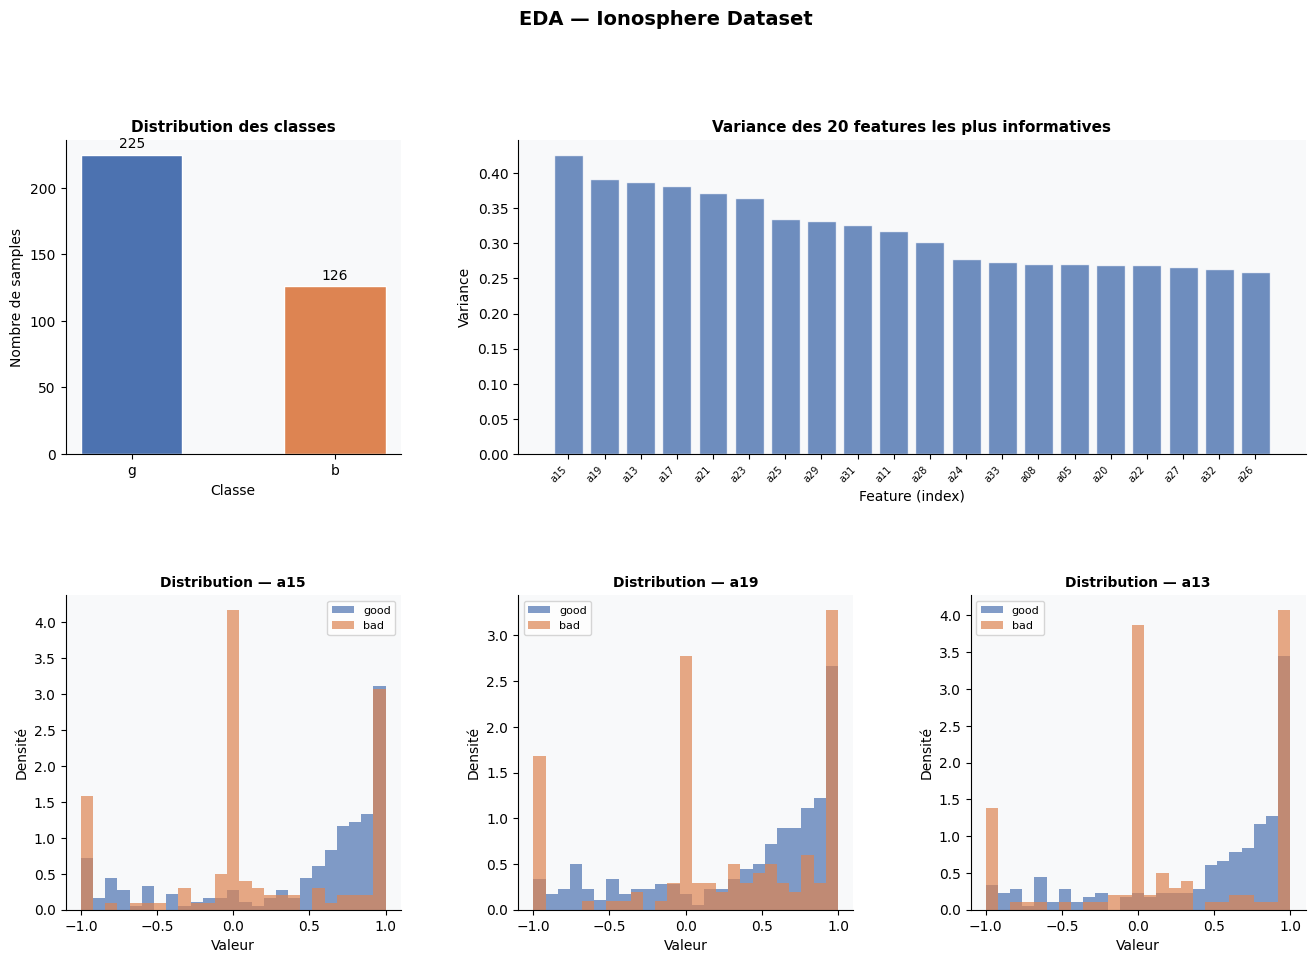

In [ ]:
# Chargement
data = fetch_openml(name='ionosphere', version=1, as_frame=True, parser='auto')
X_raw = data.data.astype(float).copy()
y_raw = data.target.copy()

print("IONOSPHERE — APERÇU GÉNÉRAL")
print(f"  Samples      : {X_raw.shape[0]}")
print(f"  Features     : {X_raw.shape[1]}")
print(f"  Classes      : {dict(y_raw.value_counts())}")
print(f"  Valeurs NaN  : {X_raw.isnull().sum().sum()}")

# Feature constante 
std_per_feature = X_raw.std()
constant_cols = std_per_feature[std_per_feature == 0].index.tolist()
print(f"\n  Features constantes : {constant_cols}  → supprimées")

# Statistiques descriptives 
print("\n  STATISTIQUES DESCRIPTIVES (premières features)")
print(X_raw.drop(columns=constant_cols).iloc[:, :8].describe().round(3).to_string())

#  Variance par feature
print("  FEATURES À FAIBLE VARIANCE (std < 0.1)")
low_var = std_per_feature[std_per_feature < 0.1].drop(constant_cols)
print(low_var if not low_var.empty else "  Aucune (hors colonnes constantes)")

# Séparation par classe pour EDA 
X_eda = X_raw.drop(columns=constant_cols).copy()
X_eda['label'] = y_raw.values
X_g = X_eda[X_eda['label'] == 'g'].drop(columns='label')
X_b = X_eda[X_eda['label'] == 'b'].drop(columns='label')

print("\n  MOYENNES PAR CLASSE (5 premières features)")
print(pd.DataFrame({'good': X_g.mean(), 'bad': X_b.mean()}).iloc[:5].round(3).to_string())

# Visualisations EDA 
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = ['#4C72B0', '#DD8452']

# Distribution des classes
ax0 = fig.add_subplot(gs[0, 0])
class_counts = y_raw.value_counts()
bars = ax0.bar(class_counts.index, class_counts.values, color=colors, width=0.5, edgecolor='white')
ax0.set_title('Distribution des classes', fontsize=11, fontweight='bold')
ax0.set_xlabel('Classe')
ax0.set_ylabel('Nombre de samples')
for bar, val in zip(bars, class_counts.values):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val),
             ha='center', va='bottom', fontsize=10)
ax0.set_facecolor('#f8f9fa')
ax0.spines[['top','right']].set_visible(False)

# Variance des features (top 20)
ax1 = fig.add_subplot(gs[0, 1:3])
var_sorted = X_raw.drop(columns=constant_cols).var().sort_values(ascending=False)[:20]
ax1.bar(range(len(var_sorted)), var_sorted.values, color='#4C72B0', alpha=0.8, edgecolor='white')
ax1.set_title('Variance des 20 features les plus informatives', fontsize=11, fontweight='bold')
ax1.set_xlabel('Feature (index)')
ax1.set_ylabel('Variance')
ax1.set_xticks(range(len(var_sorted)))
ax1.set_xticklabels(var_sorted.index, rotation=45, ha='right', fontsize=7)
ax1.set_facecolor('#f8f9fa')
ax1.spines[['top','right']].set_visible(False)

# Distribution de 3 features discriminantes par classe
top_features = var_sorted.index[:3].tolist()
for i, feat in enumerate(top_features):
    ax = fig.add_subplot(gs[1, i])
    ax.hist(X_g[feat], bins=25, alpha=0.7, color=colors[0], label='good', density=True)
    ax.hist(X_b[feat], bins=25, alpha=0.7, color=colors[1], label='bad', density=True)
    ax.set_title(f'Distribution — {feat}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.set_facecolor('#f8f9fa')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('EDA — Ionosphere Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.show();

In [ ]:
# ── Preprocessing ──────────────────────────────────────────────────────────────
X_clean = X_raw.drop(columns=constant_cols).values
y_encoded = np.where(y_raw.values == 'g', 1.0, -1.0)

# Split 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

# Implémentation LS-SVM from scratch 
class LSSVM:
    """
    Least Squares SVM — noyau RBF.
    Résout le système KKT linéaire : pas de QP.
    """
    def __init__(self, gamma=10.0, sigma=1.0):
        self.gamma = gamma   
        self.sigma = sigma   

    def _rbf(self, A, B):
        sq = (np.sum(A**2, axis=1, keepdims=True)
              + np.sum(B**2, axis=1)
              - 2 * A @ B.T)
        return np.exp(-sq / (2 * self.sigma**2))

    def fit(self, X, y):
        self.X_tr = X
        self.y_tr = y
        n = X.shape[0]

        K     = self._rbf(X, X)                     
        Omega = K * np.outer(y, y)                   
        H     = Omega + (1.0 / self.gamma) * np.eye(n)

        # Système KKT augmenté
        A_mat = np.block([
            [np.zeros((1, 1)),  np.ones((1, n))],
            [np.ones((n, 1)),   H             ]
        ])
        b_vec = np.concatenate([[0.0], y])

        sol      = solve(A_mat, b_vec)
        self.b_  = sol[0]
        self.alpha_ = sol[1:]
        return self

    def decision_function(self, X):
        K = self._rbf(X, self.X_tr)
        return K @ (self.alpha_ * self.y_tr) + self.b_

    def predict(self, X):
        return np.sign(self.decision_function(X))


# Entraînement
model = LSSVM(gamma=10.0, sigma=1.0)
model.fit(X_train, y_train)

# Évaluation 
def evaluate(model, X, y, split_name):
    y_pred  = model.predict(X)
    y_score = model.decision_function(X)
    auc     = roc_auc_score(y, y_score)
    print(f"\n{split_name}")
    print(classification_report(y, y_pred, target_names=['bad (-1)', 'good (+1)']))
    print(f"  ROC-AUC : {auc:.4f}")
    return y_pred, y_score

y_pred_val,  y_score_val  = evaluate(model, X_val,  y_val,  "VALIDATION SET")


Train : 245 samples
Val   : 53 samples
Test  : 53 samples

  VALIDATION SET
              precision    recall  f1-score   support

    bad (-1)       0.82      0.95      0.88        19
   good (+1)       0.97      0.88      0.92        34

    accuracy                           0.91        53
   macro avg       0.89      0.91      0.90        53
weighted avg       0.91      0.91      0.91        53

  ROC-AUC : 0.9551


In [4]:
y_pred_test, y_score_test = evaluate(model, X_test, y_test, "TEST SET")


  TEST SET
              precision    recall  f1-score   support

    bad (-1)       0.76      0.68      0.72        19
   good (+1)       0.83      0.88      0.86        34

    accuracy                           0.81        53
   macro avg       0.80      0.78      0.79        53
weighted avg       0.81      0.81      0.81        53

  ROC-AUC : 0.9149


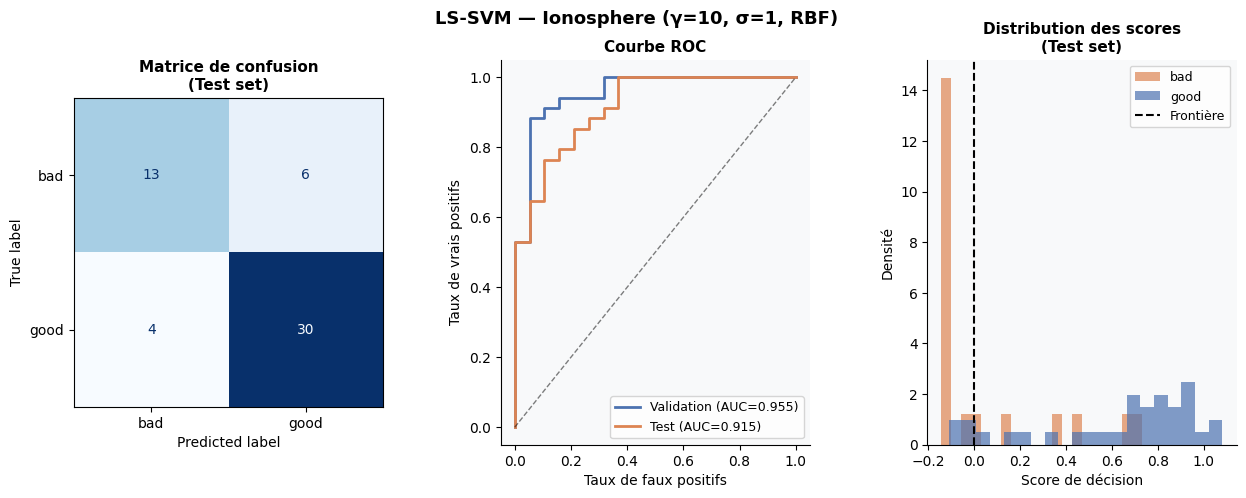

In [6]:
# Panel de visualisation
fig = plt.figure(figsize=(15, 5))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Matrice de confusion 
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad', 'good'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matrice de confusion\n(Test set)', fontsize=11, fontweight='bold')
ax1.set_facecolor('white')

# Courbe ROC — val + test 
ax2 = fig.add_subplot(gs[0, 1])
for y_true, y_score, label, color in [
    (y_val,  y_score_val,  'Validation', '#4C72B0'),
    (y_test, y_score_test, 'Test',       '#DD8452')
]:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax2.set_xlabel('Taux de faux positifs')
ax2.set_ylabel('Taux de vrais positifs')
ax2.set_title('Courbe ROC', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top','right']].set_visible(False)

#  Distribution des scores de décision 
ax3 = fig.add_subplot(gs[0, 2])
for val, label, color in [
    (y_score_test[y_test == -1], 'bad',  '#DD8452'),
    (y_score_test[y_test ==  1], 'good', '#4C72B0')
]:
    ax3.hist(val, bins=20, alpha=0.7, color=color, label=label, density=True)
ax3.axvline(0, color='black', linestyle='--', lw=1.5, label='Frontière')
ax3.set_xlabel('Score de décision')
ax3.set_ylabel('Densité')
ax3.set_title('Distribution des scores\n(Test set)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.set_facecolor('#f8f9fa')
ax3.spines[['top','right']].set_visible(False)

fig.suptitle('LS-SVM — Ionosphere (γ=10, σ=1, RBF)', fontsize=13, fontweight='bold')
plt.show();